In [24]:
# 🔧 DIAGNÓSTICO DE ERRO CUDA - Execute antes de treinar
import torch
import torch.cuda as cuda

print("="*80)
print("📊 DIAGNÓSTICO DO SISTEMA GPU")
print("="*80)

# Verificar GPU
print(f"CUDA disponível: {torch.cuda.is_available()}")
print(f"GPU encontrada: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'Nenhuma'}")

if torch.cuda.is_available():
    # Limpar cache antes de começar
    print("\n🧹 Limpando cache de GPU...")
    torch.cuda.empty_cache()
    torch.cuda.reset_peak_memory_stats()

    # Informações de memória
    props = torch.cuda.get_device_properties(0)
    total_memory = props.total_memory / 1e9
    print(f"Memória total da GPU: {total_memory:.2f} GB")

    allocated = torch.cuda.memory_allocated() / 1e9
    reserved = torch.cuda.memory_reserved() / 1e9
    print(f"Memória alocada: {allocated:.2f} GB")
    print(f"Memória reservada: {reserved:.2f} GB")
    print(f"Memória livre: {(total_memory - reserved):.2f} GB")

    # Verificar compatibilidade
    print(f"\nVersão CUDA: {torch.version.cuda}")
    print(f"Versão cuDNN: {torch.backends.cudnn.version()}")
    print(f"cuDNN habilitado: {torch.backends.cudnn.enabled}")

else:
    print("⚠️  CUDA não disponível! Usando CPU (muito lento).")

print("="*80 + "\n")

📊 DIAGNÓSTICO DO SISTEMA GPU
CUDA disponível: False
GPU encontrada: Nenhuma
⚠️  CUDA não disponível! Usando CPU (muito lento).



In [25]:
import pandas as pd
from PIL import Image, ImageChops
import numpy as np
import torch
from sklearn.model_selection import KFold
from torch.utils.data import  DataLoader, TensorDataset, Dataset
from torch import nn
import timm
from tqdm.notebook import tqdm
import torch.optim as optim
import os

In [26]:

FILE_PATH = '../dataset/dataset_AFIB_OUTROS_NORMAL_HOTENCODING.csv'

print("Iniciando o programa...")
print("Parametros de Execucao:")
folds = 2
epochs = 30
BATCH_SIZE = 64  # ✅ REDUZIDO de 64 para 32 (evita erro CUDA)
N_samples = 1000
flg_salvar_modelos = True
path = '/home/leo/Documents/ecg_classifier/dataset/database_ptbxl/'
path_out = 'saida_123/saidas/'

print(f"  Numero de folds para K-Fold Cross Validation: {folds}")

print(f"  Tamanho do batch para treinamento: {BATCH_SIZE}")

print(f"  Numero de epocas para treinamento: {epochs}")


Iniciando o programa...
Parametros de Execucao:
  Numero de folds para K-Fold Cross Validation: 2
  Tamanho do batch para treinamento: 64
  Numero de epocas para treinamento: 30


In [27]:
## Data augumentation concat. 
FILE_PATH_AUG = 'dataset_AFIB_Others/dataset_aug.csv'
path_aug = 'dataset_AFIB_Others/data/'


In [28]:
from PIL import Image, ImageChops
import numpy as np
import os
import shutil
import io
from pathlib import Path
def treat_image_PIL(img_path, type_return=2):
    ''''
    Input: Img_path, type return.

    Img_path: path da imagem em formato png, img...
    type_return: 1-> retorno como PIL.
                2 ou sem type_return -> retorno como numpy array tipo uint8

    Output:
    '''
    im = Image.open(path+img_path)

    # Size of the image in pixels (size of original image)
    # (This is not mandatory)
    width, height = im.size

    rgb =Image.Image.split(im)

    data =rgb
    b= data[0]
    g= data[1]
    r= data[2]
    #img_out = b+g+.5*r
    #img_out_2 = img_out[500:1600, 50:2100]

    newsize = (256, 256)
   # im3 =ImageChops.subtract(mask,b, scale=1.0, offset=0)

    b1 = b.crop((120,500,2100,1600))
    g1 = g.crop((120,500,2100,1600))
    r1 = r.crop((120,500,2100,1600))
    im1 = b1.resize(newsize, Image.Resampling.LANCZOS).convert('L')
    im2 = g1.resize(newsize, Image.Resampling.LANCZOS).convert('L')
    im3 = r1.resize(newsize, Image.Resampling.LANCZOS).convert('L')
    if type_return ==1:
        return Image.merge("RGB",(im1,im1,im1))
    elif type_return ==2:

        return np.array(im1,dtype=np.uint8)
    elif type_return ==3:

        return np.array([im1,im2,im3],dtype=np.uint8)
    elif type_return ==4:

        return np.array(im3,dtype=np.uint8)

def save_file_to_dir(file_obj, directory, filename):
    """
    Save a file to `directory` with the given `filename`.

    Parameters
    - file_obj: a PIL Image, a filesystem path (str or Path) to an existing file,
                bytes/bytearray, or a file-like object with a .read() method.
    - directory: target directory where the file will be saved.
    - filename: the name to use for the saved file (including extension if desired).

    Returns
    - full path (str) to the saved file.

    Raises
    - FileNotFoundError if a provided source path does not exist.
    - ValueError if the provided file_obj type is unsupported.
    """
    os.makedirs(directory, exist_ok=True)
    dest = os.path.join(directory, filename)

    # PIL Image
    if isinstance(file_obj, Image.Image):
        file_obj.save(dest)
        return dest

    # Path-like or string pointing to an existing file
    if isinstance(file_obj, (str, Path)):
        src = str(file_obj)
        if os.path.exists(src):
            shutil.copy(src, dest)
            return dest
        raise FileNotFoundError(f"Source path not found: {src}")

    # File-like object
    if hasattr(file_obj, "read"):
        data = file_obj.read()
        # If read() returned bytes -> try open as image, otherwise write raw
        if isinstance(data, (bytes, bytearray)):
            try:
                img = Image.open(io.BytesIO(data))
                img.save(dest)
                return dest
            except Exception:
                with open(dest, "wb") as f:
                    f.write(data)
                return dest
        else:
            # assume text
            with open(dest, "w", encoding="utf-8") as f:
                f.write(data)
            return dest

    # Raw bytes
    if isinstance(file_obj, (bytes, bytearray)):
        try:
            img = Image.open(io.BytesIO(file_obj))
            img.save(dest)
            return dest
        except Exception:
            with open(dest, "wb") as f:
                f.write(file_obj)
            return dest

    raise ValueError("file_obj must be a PIL.Image, path string/Path, bytes or file-like object")

In [29]:
## Exemplo de uso de resize de imagem
image  = treat_image_PIL('00004_lr-0.png',1)
display(image)

## treat image pil as array and return to Image PIL and display
img_array = treat_image_PIL('00004_lr-0.png',3)
print(img_array.shape)
print(img_array.dtype)
img_pil = Image.fromarray(img_array.transpose(1, 2, 0))  # (3, 256, 256) → (256, 256, 3)
display(img_pil)

FileNotFoundError: [Errno 2] No such file or directory: '/home/leo/Documents/ecg_classifier/dataset/database_ptbxl/00004_lr-0.png'

In [30]:
import os
## Cria funcao para validar se pasta a ser inserida existe. Caso nao exista, cria a pasta
def create_folder_if_not_exists(folder_path):
    if not os.path.exists(folder_path):
        os.makedirs(folder_path)
        print(f'Pasta {folder_path} criada.')
    else:
        print(f'Pasta {folder_path} ja existe.')


In [31]:
from torch.utils.data import  Dataset

class Subset(Dataset):
    r"""
    Subset of a dataset at specified indices.

    Arguments:
        dataset (Dataset): The whole Dataset
        indices (sequence): Indices in the whole set selected for subset
    """
    def __init__(self, dataset, indices):
        self.dataset = dataset
        self.indices = indices

    def __getitem__(self, idx):
        return self.dataset[self.indices[idx]]

    def __len__(self):
        return len(self.indices)

    @property
    def classes(self):
        return self.data.classes

    def shape(self):
        return self.dataset

In [32]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print("Device: " + str(device))

Device: cpu


In [33]:
import torch
from torch import nn
import numpy as np
import os
import torch.optim as optim
from tqdm import tqdm
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
from torch.cuda.amp import autocast, GradScaler
from torch.optim.lr_scheduler import ReduceLROnPlateau

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print("Device: " + str(device))

def salvar_model(model, path = '/content/drive/MyDrive/4000-files/output/modelos', name_file='model.pth'):
    create_folder_if_not_exists(path)

    full_path = os.path.join(path, name_file)
    torch.save(model.state_dict(), full_path)

def salvar_metricas(path, name_file_train='train_loss_total.npy', name_file_val='val_loss_total.npy',predict_label=None, true_label=None):
    create_folder_if_not_exists(path)
    full_path_train = os.path.join(path, name_file_train)
    full_path_val = os.path.join(path, name_file_val)
    np.save(full_path_train, np.array(predict_label))
    np.save(full_path_val, np.array(true_label))
    print(f'Metricas salvas em {path} com os nomes {name_file_train} e {name_file_val} e tamanhos {np.array(predict_label).shape} e {np.array(true_label).shape}')

def simple_loop(model, train_image, val_image, epochs, batch_size, fold_index, patience=10, delta=0.0001, device_input=None):
    """
    Loop de treinamento e validação com Early Stopping, regularização e monitoramento de métricas.
    ✅ MELHORIAS: Mixed Precision, detecção CUDA, garantir float32, device handling

    Parâmetros adicionais:
        patience (int): Número de épocas sem melhora antes de parar (default: 10)
        delta (float): Threshold mínimo de melhora para considerar como melhora (default: 0.001)
        device_input: torch.device('cuda:0') ou torch.device('cpu')
    """
    # Use device global se não fornecido
    if device_input is None:
        device_input = device

    # Simple training loop
    num_epochs = epochs
    train_losses, val_losses = [], []
    train_accuracies, val_accuracies = [], []
    train_f1s, val_f1s = [], []
    lim_loss = 1.5
    iter_size = batch_size
    print(f'Number of training images per iteration: {iter_size}')
    print(f'Device sendo usado: {device_input}')

    # ✅ IMPORTANTE: Move model para device PRIMEIRO
    try:
        #model = model.to(device_input)
        print(f'✓ Modelo movido para {device_input}')
    except Exception as e:
        print(f'❌ ERRO ao mover modelo para device: {e}')
        raise


    criterion = nn.CrossEntropyLoss()
    # Optimizer COM regularização (weight_decay)
    optimizer = optim.Adam(model.parameters(), lr=0.0001, weight_decay=1e-4)
    scheduler = ReduceLROnPlateau(optimizer, "min", patience=3)
    predict_label_full_train = []
    predict_label_full = []
    true_label_full_train = []
    true_label_full = []

    for epoch in range(num_epochs):
        # Training phase
        model.train()
        predict_label_train = []
        true_label_train = []
        running_loss_train = 0.0

        try:
            for images, labels in tqdm(train_image, desc='Training loop'):
                # ✅ FIX: Garantir float32 e evitar overflow
                images = images.to(torch.float32)
                labels = labels.to(torch.long)
                optimizer.zero_grad()

                # ✅ FIX: Usar autocast para mixed precision

                outputs = model(images)

                pred_train = torch.argmax(outputs, dim=1)
                _true = labels.squeeze()
                loss_train = criterion(outputs.to(torch.float32), _true)
                loss_train.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()

                _pred_train = torch.argmax(outputs, dim=1)
                running_loss_train += loss_train.item() * labels.size(0)

                # Salvar predições e labels CORRETAMENTE
                try:
                    pred_list = _pred_train.cpu().detach().numpy().astype(int).tolist()
                    true_list = labels.squeeze().cpu().detach().numpy().astype(int).tolist()

                    if not isinstance(pred_list, list):
                        pred_list = [pred_list]
                    if not isinstance(true_list, list):
                        true_list = [true_list]

                    if len(pred_list) == iter_size:
                        predict_label_train.append(pred_list)
                        true_label_train.append(true_list)

                except Exception as e:
                    print(f"⚠ Erro ao salvar predições de treinamento: {e}")

        except RuntimeError as e:
            if "CUDA" in str(e) or "assert" in str(e).lower():
                print(f"\n❌ ERRO CUDA durante treinamento: {e}")
                print("💡 Sugestões:")
                print("   1. Reduza BATCH_SIZE")
                print("   2. Execute torch.cuda.empty_cache()")
                print("   3. Use modelos menores")
                torch.cuda.empty_cache()
                raise
            else:
                raise

        train_loss = running_loss_train / len(train_image.dataset)
        train_losses.append(train_loss)

        # Calcular métricas de treinamento
        try:
            if predict_label_train and true_label_train:
                train_preds = np.concatenate(predict_label_train)
                train_trues = np.concatenate(true_label_train)
                train_acc = accuracy_score(train_trues, train_preds)
                train_f1 = f1_score(train_trues, train_preds, average='weighted', zero_division=0)
                train_accuracies.append(train_acc)
                train_f1s.append(train_f1)
        except Exception as e:
            print(f"⚠ Erro ao calcular métricas de treinamento: {e}")

        try:
            _p_train = predict_label_train
            _t_train = true_label_train
            predict_label_full_train.append(_p_train)
            true_label_full_train.append(_t_train)
        except Exception as e:
            print(f"⚠ Erro ao concatenar métricas de treinamento: {e}")

        # Validation phase
        model.eval()
        running_loss_valid = 0.0
        predict_label = []
        true_label = []
        _iter = 0

        try:
            with torch.no_grad():
                for images, labels in tqdm(val_image, desc='Validation loop'):
                    # ✅ FIX: Garantir float32
                    images = images.to(torch.float32)
                    labels = labels.to(torch.long)
                    outputs = model(images)

                    loss_valid = criterion(outputs.to(torch.float32), labels.squeeze())

                    # Get predictions
                    _pred = torch.argmax(outputs, dim=1)

                    # Salvar predições e labels
                    try:
                        pred_list = _pred.cpu().numpy().astype(int).tolist()
                        true_list = labels.squeeze().cpu().numpy().astype(int).tolist()

                        if not isinstance(pred_list, list):
                            pred_list = [pred_list]
                        if not isinstance(true_list, list):
                            true_list = [true_list]

                        if len(pred_list) == iter_size:
                            predict_label.append(pred_list)
                            true_label.append(true_list)

                    except Exception as e:
                        print(f"⚠ Erro ao salvar predições de validação: {e}")

                    running_loss_valid += loss_valid.item() * labels.size(0)
                    _iter += 1

        except RuntimeError as e:
            if "CUDA" in str(e) or "assert" in str(e).lower():
                print(f"\n❌ ERRO CUDA durante validação: {e}")
                torch.cuda.empty_cache()
                raise
            else:
                raise

        val_loss = running_loss_valid / len(val_image.dataset)
        val_losses.append(val_loss)
        scheduler.step(val_loss)

        # Calcular métricas de validação
        val_precision = 0
        val_recall = 0
        try:
            if predict_label and true_label:
                val_preds = np.concatenate(predict_label)
                val_trues = np.concatenate(true_label)
                val_acc = accuracy_score(val_trues, val_preds)
                val_f1 = f1_score(val_trues, val_preds, average='weighted', zero_division=0)
                val_precision = precision_score(val_trues, val_preds, average='weighted', zero_division=0)
                val_recall = recall_score(val_trues, val_preds, average='weighted', zero_division=0)
                val_accuracies.append(val_acc)
                val_f1s.append(val_f1)
        except Exception as e:
            print(f"⚠ Erro ao calcular métricas de validação: {e}")

        try:
            _p = predict_label
            _t = true_label
            predict_label_full.append(_p)
            true_label_full.append(_t)
        except Exception as e:
            print(f"⚠ Erro ao concatenar métricas de validação: {e}")

        # Print detalhado das métricas
        print(f"\n{'='*80}")
        print(f"Epoch {epoch+1}/{num_epochs}")
        print(f"{'='*80}")
        print(f"Train Loss: {train_loss:.6f}", end="")
        if train_accuracies:
            print(f" | Train Acc: {train_accuracies[-1]:.4f}", end="")
            print(f" | Train F1: {train_f1s[-1]:.4f}", end="")

        print()
        print(f"Val Loss:   {val_loss:.6f}", end="")
        if val_accuracies:
            print(f" | Val Acc: {val_accuracies[-1]:.4f}", end="")
            print(f" | Val F1: {val_f1s[-1]:.4f}", end="")
            print(f" | Precision: {val_precision:.4f}", end="")
            print(f" | Recall: {val_recall:.4f}", end="")
        print()
        print(f"{'='*80}\n")

    predict_label_full_out = np.array(predict_label_full, dtype=object)
    true_label_full_out = np.array(true_label_full, dtype=object)
    predict_label_full_train_out = np.array(predict_label_full_train, dtype=object)
    true_label_full_train_out = np.array(true_label_full_train, dtype=object)
    print(f'Salvado das metricas de validacao e treino')

    salvar_metricas(path=f'{path_out}/output/metricas/valid/fold_{fold_index}',
                    name_file_train=f'predict_label_valid_fold_{fold_index}.npy',
                    name_file_val=f'true_label_valid_fold_{fold_index}.npy',
                    predict_label= predict_label_full_out, true_label= true_label_full_out)

    salvar_metricas(path=f'{path_out}/output/metricas/train/fold_{fold_index}',
                    name_file_train=f'predict_label_train_fold_{fold_index}.npy',
                    name_file_val=f'true_label_train_fold_{fold_index}.npy',
                    predict_label= predict_label_full_train_out, true_label= true_label_full_train_out)
    print(f'Finalizado o salvamento das metricas')
    return train_losses, val_losses, model, predict_label_full_out, true_label_full_out

Device: cpu


In [34]:
#from models import ECGClassifierResnet
from torch import nn
import timm
class ECGClassifierResnet(nn.Module):
    def __init__(self, num_classes=1):
        super(ECGClassifierResnet, self).__init__()
        # Where we define all the parts of the model
        #self.base_model = timm.create_model('efficientnet_b0', pretrained=True)
        self.base_model=timm.create_model('resnet50d.ra4_e3600_r224_in1k',pretrained=True)
        #self.base_model = timm.create_model('vit_mediumd_patch16_reg4_gap_256.sbb2_e200_in12k_ft_in1k',num_classes=5,pretrained=True)

        self.features = nn.Sequential(*list(self.base_model.children())[:-1])

        enet_out_size = 2048        # Make a classifier
        # For binary classification com Dropout para regularização
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.7),           # Dropout para regularização (reduz overfitting)
            nn.ReLU(),
            nn.Dropout(0.5),           # Dropout adicional antes da saída
            nn.Linear(enet_out_size, 3)
        ) # saida como Softmax para classificacao single label

    def forward(self, x):
        # Connect these parts and return the output
        #converte 1 canal para 3 canais (RGB) usando uma camada Conv2d
        #x1 = nn.Conv2d(3, 1, kernel_size=3, stride=1, padding=1)(x)  # Converte de 1 canal para 3 canais
        x = self.features(x)
        output = self.classifier(x)
        #output = nn.Softmax(dim=1)(output)
        return output


In [35]:
#from models import ECGClassifierResnet
from torch import nn
import timm
class ECGClassifierMambaVision(nn.Module):
    def __init__(self, num_classes=1):
        super(ECGClassifierMambaVision, self).__init__()
        # Where we define all the parts of the model
        #self.base_model = timm.create_model('efficientnet_b0', pretrained=True)
        self.base_model=timm.create_model('mamba_vision_L2',pretrained=True)
        #self.base_model = timm.create_model('vit_mediumd_patch16_reg4_gap_256.sbb2_e200_in12k_ft_in1k',num_classes=5,pretrained=True)

        self.features = nn.Sequential(*list(self.base_model.children())[:-1])

        enet_out_size = 2048        # Make a classifier
        # For binary classification com Dropout para regularização
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.7),           # Dropout para regularização (reduz overfitting)
            nn.ReLU(),
            nn.Dropout(0.5),           # Dropout adicional antes da saída
            nn.Linear(enet_out_size, 2)
        ) # saida como Softmax para classificacao single label

    def forward(self, x):
        # Connect these parts and return the output
        #converte 1 canal para 3 canais (RGB) usando uma camada Conv2d
        #x1 = nn.Conv2d(3, 1, kernel_size=3, stride=1, padding=1)(x)  # Converte de 1 canal para 3 canais
        x = self.features(x)
        output = self.classifier(x)
        #output = nn.Softmax(dim=1)(output)
        return output




In [ ]:
## Funções Otimizadas para Leitura de CSV e Carregamento de Imagens

import os
import psutil
from pathlib import Path

def explore_csv(csv_path, max_rows=5):
    """
    Explora arquivo CSV fornecendo informações detalhadas.

    Parâmetros:
        csv_path (str): Caminho do arquivo CSV
        max_rows (int): Número de linhas para exibir

    Retorna:
        pd.DataFrame: Dados carregados
    """
    print("="*80)
    print("📋 EXPLORAÇÃO DO ARQUIVO CSV")
    print("="*80)

    # Verificar se arquivo existe
    if not os.path.exists(csv_path):
        print(f"❌ ERRO: Arquivo não encontrado: {csv_path}")
        return None

    print(f"✓ Arquivo encontrado: {csv_path}")
    print(f"  Tamanho do arquivo: {os.path.getsize(csv_path) / (1024*1024):.2f} MB")

    ## rename 0 col to path , 1 col to label and 2 col to patient id if exists
    # map col label to AFIB =1 and Others = 0

    try:
        # Ler CSV
        print("\n📖 Lendo arquivo CSV...")
        data = pd.read_csv(csv_path)

        print(f"✓ CSV lido com sucesso!")
        print(f"  Shape: {data.shape} (linhas, colunas)")
        print(f"  Colunas: {list(data.columns)}")
        print(f"  Tipos de dados:\n{data.dtypes}\n")

        # Verificar valores nulos
        print("📊 Valores Nulos:")
        null_counts = data.isnull().sum()
        if null_counts.sum() == 0:
            print("  ✓ Nenhum valor nulo encontrado!")
        else:
            print(f"  ⚠ Valores nulos encontrados:\n{null_counts}\n")

        # Primeiras linhas
        print(f"📄 Primeiras {max_rows} linhas:")
        print(data.head(max_rows).to_string())

        # Estatísticas
        print(f"\n📈 Estatísticas básicas:")
        print(f"  Total de amostras: {len(data)}")
        if data.shape[1] >= 2:
            label_col = data.columns[-1]
            print(f"  Distribuição de labels ({label_col}):")
            print(data[label_col].value_counts().to_string())

        print("="*80)
        return data

    except Exception as e:
        print(f"❌ ERRO ao ler CSV: {e}")
        return None


def validate_and_load_images(data, image_path_prefix, n_samples=None, max_errors=10):
    """
    Valida e carrega imagens com tratamento robusto de erros.

    Parâmetros:
        data (pd.DataFrame): DataFrame com caminhos das imagens
        image_path_prefix (str): Prefixo do caminho das imagens
        n_samples (int): Número de amostras a carregar (None = todas)
        max_errors (int): Máximo de erros antes de parar

    Retorna:
        tuple: (img_dataset, data_valid, error_count)
    """
    print("\n" + "="*80)
    print("🖼️  VALIDAÇÃO E CARREGAMENTO DE IMAGENS")
    print("="*80)

    # Preparar dados
    if n_samples is not None:
        data_sample = data.sample(n=min(n_samples, len(data)), random_state=42).reset_index(drop=True)
    else:
        data_sample = data.reset_index(drop=True)

    print(f"\n📌 Configuração:")
    print(f"  Amostras a processar: {len(data_sample)}")
    print(f"  Prefixo de caminho: {image_path_prefix}")
    print(f"  Máximo de erros permitidos: {max_errors}")

    # Verificar memória disponível
    memory_info = psutil.virtual_memory()
    print(f"\n💾 Memória disponível: {memory_info.available / (1024**3):.2f} GB")
    estimated_memory = (len(data_sample) * 3 * 256 * 256 * 1) / (1024**3)
    print(f"  Memória estimada para imagens: {estimated_memory:.2f} GB")

    if estimated_memory > memory_info.available * 0.8:
        print(f"  ⚠ AVISO: Uso de memória pode ser alto!")

    # Preparar array
    img_dataset = np.zeros((len(data_sample),3,256, 256), dtype=np.uint8)
    error_indices = []
    error_count = 0

    print(f"\n🔄 Carregando imagens...")

    for idx, row in tqdm(data_sample.iterrows(), total=len(data_sample), desc='Carregando imagens'):
        try:
            img_path = row.iloc[1]  # Primeira coluna = caminho
            full_path = os.path.join(image_path_prefix, img_path)

            # Verificar se arquivo existe
            if not os.path.exists(full_path):
                raise FileNotFoundError(f"Imagem não encontrada: {full_path}")

            # Carregar imagem
            img = treat_image_PIL(img_path, type_return=3)


            img_dataset[idx] = img

        except Exception as e:
            error_count += 1
            error_indices.append(idx)

            if error_count == 1:
                print(f"\n⚠ Erros encontrados durante carregamento:")

            print(f"  Erro na amostra {idx}: {type(e).__name__}: {str(e)[:60]}")

            if error_count >= max_errors:
                print(f"\n❌ Máximo de {max_errors} erros atingido. Parando...")
                break

    # Remover amostras com erro
    if error_indices:
        print(f"\n🧹 Removendo {len(error_indices)} amostras com erro...")
        valid_indices = [i for i in range(len(data_sample)) if i not in error_indices]
        img_dataset = img_dataset[valid_indices]
        data_sample = data_sample.iloc[valid_indices].reset_index(drop=True)

    print("\n✅ Carregamento concluído!")
    print(f"  Imagens carregadas com sucesso: {len(img_dataset)}")
    print(f"  Imagens com erro: {error_count}")
    print(f"  Shape final: {img_dataset.shape}")
    print("="*80)

    return img_dataset, data_sample, error_count


def get_image_statistics(img_dataset):
    """Calcula estatísticas das imagens carregadas."""
    print("\n" + "="*80)
    print("📊 ESTATÍSTICAS DAS IMAGENS")
    print("="*80)

    print(f"Shape: {img_dataset.shape}")
    print(f"Tipo de dado: {img_dataset.dtype}")
    print(f"Min: {img_dataset.min()}")
    print(f"Max: {img_dataset.max()}")
    print(f"Média: {img_dataset.mean():.2f}")
    print(f"Std: {img_dataset.std():.2f}")
    print(f"Memória total: {img_dataset.nbytes / (1024**2):.2f} MB")
    print("="*80)


In [49]:
print(f"Leitura e carregamento otimizado do arquivo '{FILE_PATH}'...\n")

## concat file_path and file_path_aug and read both csvs and concatenate the dataframes

# 1️⃣ EXPLORAR CSV PRIMEIRO
data = explore_csv(FILE_PATH, max_rows=10)[0:N_samples]


## CSV concat com data augumentation
#data_aug = explore_csv(FILE_PATH_AUG, max_rows=10)

#data = pd.concat([data, data_aug], ignore_index=True)
print(f"\n📌 Após concatenação com data augmentation: {len(data)} amostras") 


Leitura e carregamento otimizado do arquivo '../dataset/dataset_AFIB_OUTROS_NORMAL_HOTENCODING.csv'...

📋 EXPLORAÇÃO DO ARQUIVO CSV
✓ Arquivo encontrado: ../dataset/dataset_AFIB_OUTROS_NORMAL_HOTENCODING.csv
  Tamanho do arquivo: 1.11 MB

📖 Lendo arquivo CSV...
✓ CSV lido com sucesso!
  Shape: (21799, 10) (linhas, colunas)
  Colunas: ['patient_id', 'age', 'sex', 'height', 'weight', 'diagnostic_superclass', 'path', 'NORMAL_LABEL', 'RITM_NAO_AFIB', 'AFIB']
  Tipos de dados:
patient_id               float64
age                      float64
sex                        int64
height                   float64
weight                   float64
diagnostic_superclass        str
path                         str
NORMAL_LABEL               int64
RITM_NAO_AFIB              int64
AFIB                       int64
dtype: object

📊 Valores Nulos:
  ⚠ Valores nulos encontrados:
patient_id                   0
age                          0
sex                          0
height                   14825
weight

In [38]:
data
#data['patient_id'].unique()

,patient_id,age,sex,height,weight,diagnostic_superclass,path,NORMAL_LABEL,RITM_NAO_AFIB,AFIB
0,15709.0,56.0,1,NaN,63.0,['NORMAL'],00001_lr-0.png,1,0,0
1,13243.0,19.0,0,NaN,70.0,['RITM_NAO_AFIB'],00002_lr-0.png,0,1,0
2,20372.0,37.0,1,NaN,69.0,['NORMAL'],00003_lr-0.png,1,0,0
3,17014.0,24.0,0,NaN,82.0,['NORMAL'],00004_lr-0.png,1,0,0
4,17448.0,19.0,1,NaN,70.0,['NORMAL'],00005_lr-0.png,1,0,0
...,...,...,...,...,...,...,...,...,...,...
995,12978.0,55.0,1,NaN,85.0,['NORMAL'],01008_lr-0.png,1,0,0
996,2406.0,60.0,1,164.0,56.0,['NORMAL'],01009_lr-0.png,1,0,0
997,5889.0,50.0,1,160.0,85.0,['NORMAL'],01010_lr-0.png,1,0,0
998,7732.0,74.0,0,174.0,98.0,['NORMAL'],01011_lr-0.png,1,0,0


In [39]:
patient_id_list = data['patient_id'][0:None].unique()
patient_id_list

array([15709., 13243., 20372., 17014., 17448., 19005., 16193., 11275.,
       18792.,  9456., 11243., 11031., 19953., 12925., 13375., 10999.,
       13619., 11116., 17102., 20978.,  9012., 10962., 10316., 14340.,
       19053., 15348., 11154., 20527., 15539.,  8787.,  9123., 17076.,
       19501.,  8420.,  8039., 11315., 19571., 18794., 13180.,  8295.,
       13672., 13958., 16961., 16750., 18153., 21409., 16751., 20191.,
       16063., 19424., 19475., 15065., 14660., 21273., 15265., 12864.,
       19170., 11352.,  8520., 14101.,  8339., 19173., 15551., 14060.,
       19987., 11671., 18502., 21214.,  8555., 14356., 17529.,  9339.,
       20961., 19645., 11314., 19197., 15904., 10366., 17293., 15275.,
       12531.,  8418.,  8305., 10239., 10029., 21731.,  9243., 21698.,
       12761., 10804., 18012., 21404.,  9086.,  9887., 13722., 19738.,
       18974., 16066., 13453., 11810., 21312., 12715., 13266., 19832.,
       13285., 14097., 11591., 19695., 16747., 21192., 11860., 12603.,
      

In [40]:

from numpy import rint


print("Tensor de Rotulos sendo gerado...")


print(f"Configuracao do K-Fold para {folds} folds...")
kf = KFold(n_splits=5)
kf.get_n_splits(data['patient_id'].unique())
print(kf)
print("K-Fold configurado com sucesso.")

print("Iniciando o treinamento com K-Fold Cross Validation...")

train_loss_total = []
val_loss_total =[]
all_models =[]
patient_id_list = data['patient_id'][0:None].unique()
for train, test in kf.split(patient_id_list):
    print(f"\n{'#'*80}")
    print(f"train e val split para fold {train}  e {test}...")
    ## Obter os patient_id para treino e validação
    train_patient_ids = data.iloc[test]
    train_patient_ids = train_patient_ids['patient_id']
    print(train_patient_ids)

    dados2 = data[data['patient_id'].isin(train_patient_ids)]
    print(dados2.index)
    print(f"\n{'#'*80}")

    val_patient_ids = data.iloc[train]
    val_patient_ids = val_patient_ids['patient_id']
    print(val_patient_ids)
    dados2 = data[data['patient_id'].isin(val_patient_ids)]
    print(dados2.index)
    print(f"\n{'#A'*80}")
    



Tensor de Rotulos sendo gerado...
Configuracao do K-Fold para 2 folds...
KFold(n_splits=5, random_state=None, shuffle=False)
K-Fold configurado com sucesso.
Iniciando o treinamento com K-Fold Cross Validation...

################################################################################
train e val split para fold [187 188 189 190 191 192 193 194 195 196 197 198 199 200 201 202 203 204
 205 206 207 208 209 210 211 212 213 214 215 216 217 218 219 220 221 222
 223 224 225 226 227 228 229 230 231 232 233 234 235 236 237 238 239 240
 241 242 243 244 245 246 247 248 249 250 251 252 253 254 255 256 257 258
 259 260 261 262 263 264 265 266 267 268 269 270 271 272 273 274 275 276
 277 278 279 280 281 282 283 284 285 286 287 288 289 290 291 292 293 294
 295 296 297 298 299 300 301 302 303 304 305 306 307 308 309 310 311 312
 313 314 315 316 317 318 319 320 321 322 323 324 325 326 327 328 329 330
 331 332 333 334 335 336 337 338 339 340 341 342 343 344 345 346 347 348
 349 350 351 352 353 

In [50]:
if data is None:
    print("❌ Não foi possível continuar. Verifique o arquivo CSV.")
else:
    # 2️⃣ RENOMEAR COLUNAS PARA PADRONIZAÇÃO
    print("\n🏷️  Padronizando nomes de colunas...")
    if data.shape[1] >= 2:
        # patient_id,age,sex,height,weight,diagnostic_superclass,path,NORMAL_LABEL,RITM_NAO_AFIB,AFIB   
        #data.rename(columns={data.columns[6]: 'path', data.columns[-1]: 'label', data.columns[0]: 'patient_id'}, inplace=True)
        data_patient_id = data[['patient_id','path', 'RITM_NAO_AFIB']]
        print(f"✓ Colunas renomeadas: {list(data.columns[:3])}\n")

    # 3️⃣ CARREGAR IMAGENS COM VALIDAÇÃO
    img_dataset, data_imgs, error_count = validate_and_load_images(
        data=data_patient_id,
        image_path_prefix=path,  # path definido anteriormente
        n_samples=N_samples,
        max_errors=10
    )

    # 4️⃣ ESTATÍSTICAS DAS IMAGENS
    get_image_statistics(img_dataset)

    # 5️⃣ RESUMO FINAL
    print("\n" + "="*80)
    print("✅ RESUMO FINAL DO CARREGAMENTO")
    print("="*80)
    print(f"Arquivo CSV: {FILE_PATH}")
    print(f"Total de amostras: {len(data)}")
    print(f"Shape de imagens: {img_dataset.shape}")
    print(f"Distribuição de labels:")
    print(data['RITM_NAO_AFIB'].value_counts().to_string())
    print("="*80 + "\n")

## Geracao do tensor de imagens
print("Gerando tensor de imagens a partir do dataset carregado...")
tensor_imagem = torch.from_numpy(img_dataset)
print(f"✓ Tensor de imagens gerado com shape: {tensor_imagem.shape} e dtype: {tensor_imagem.dtype}")


🏷️  Padronizando nomes de colunas...
✓ Colunas renomeadas: ['patient_id', 'age', 'sex']


🖼️  VALIDAÇÃO E CARREGAMENTO DE IMAGENS

📌 Configuração:
  Amostras a processar: 1000
  Prefixo de caminho: /home/leo/Documents/ecg_classifier/dataset/database_ptbxl/
  Máximo de erros permitidos: 10

💾 Memória disponível: 1.47 GB
  Memória estimada para imagens: 0.18 GB

🔄 Carregando imagens...


Carregando imagens:   1%|          | 9/1000 [00:00<00:17, 55.93it/s]


⚠ Erros encontrados durante carregamento:
  Erro na amostra 0: FileNotFoundError: [Errno 2] No such file or directory: '/home/leo/Documents/ec
  Erro na amostra 1: FileNotFoundError: [Errno 2] No such file or directory: '/home/leo/Documents/ec
  Erro na amostra 2: FileNotFoundError: [Errno 2] No such file or directory: '/home/leo/Documents/ec
  Erro na amostra 3: FileNotFoundError: [Errno 2] No such file or directory: '/home/leo/Documents/ec
  Erro na amostra 4: FileNotFoundError: [Errno 2] No such file or directory: '/home/leo/Documents/ec
  Erro na amostra 5: FileNotFoundError: [Errno 2] No such file or directory: '/home/leo/Documents/ec
  Erro na amostra 6: FileNotFoundError: [Errno 2] No such file or directory: '/home/leo/Documents/ec
  Erro na amostra 7: FileNotFoundError: [Errno 2] No such file or directory: '/home/leo/Documents/ec
  Erro na amostra 8: FileNotFoundError: [Errno 2] No such file or directory: '/home/leo/Documents/ec
  Erro na amostra 9: FileNotFoundError: [Errno 2


✅ Carregamento concluído!
  Imagens carregadas com sucesso: 990
  Imagens com erro: 10
  Shape final: (990, 3, 256, 256)

📊 ESTATÍSTICAS DAS IMAGENS
Shape: (990, 3, 256, 256)
Tipo de dado: uint8
Min: 0
Max: 0
Média: 0.00
Std: 0.00
Memória total: 185.62 MB

✅ RESUMO FINAL DO CARREGAMENTO
Arquivo CSV: ../dataset/dataset_AFIB_OUTROS_NORMAL_HOTENCODING.csv
Total de amostras: 1000
Shape de imagens: (990, 3, 256, 256)
Distribuição de labels:
RITM_NAO_AFIB
0    909
1     91

Gerando tensor de imagens a partir do dataset carregado...
✓ Tensor de imagens gerado com shape: torch.Size([990, 3, 256, 256]) e dtype: torch.uint8


(3, 256, 256)
uint8
(3, 256, 256)
uint8
Imagem Original:


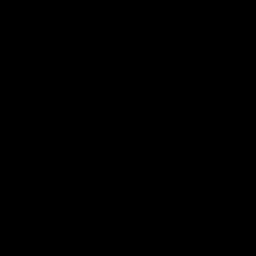

Imagem Transformada:


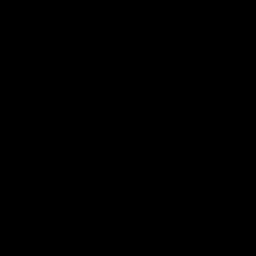

(3, 256, 256)
uint8
(3, 256, 256)
uint8
Imagem Original:


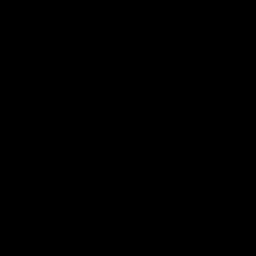

Imagem Transformada:


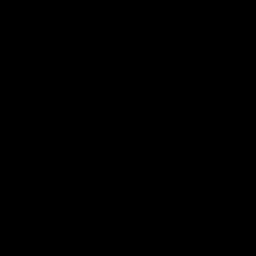

(3, 256, 256)
uint8
(3, 256, 256)
uint8
Imagem Original:


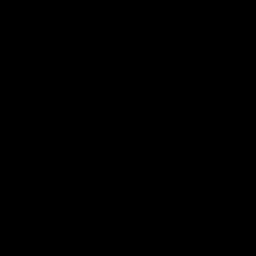

Imagem Transformada:


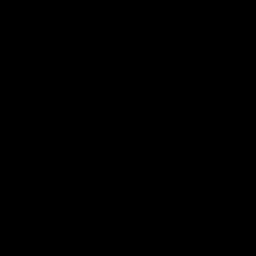

(3, 256, 256)
uint8
(3, 256, 256)
uint8
Imagem Original:


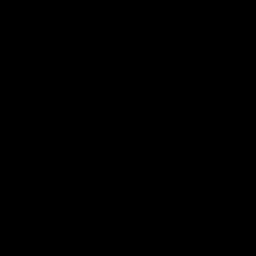

Imagem Transformada:


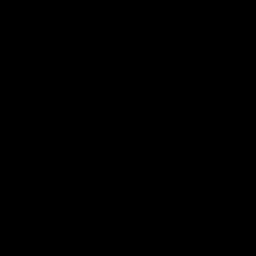

(3, 256, 256)
uint8
(3, 256, 256)
uint8
Imagem Original:


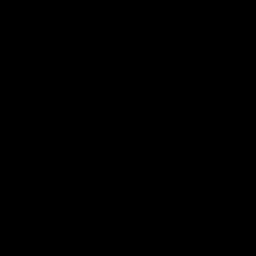

Imagem Transformada:


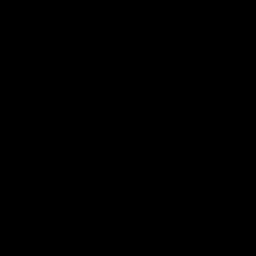

In [42]:
## crie uma transformacao de numpy para image pil e faca o display da imagem original e da imagem transformada para verificar se a transformacao esta correta
def numpy_to_pil(numpy_array):
    # Verifica se o array tem a forma correta (C, H, W)
   # if numpy_array.shape[0] != 3:
     #   raise ValueError("O array deve ter a forma (3, H, W) para ser convertido em imagem PIL.")

    print(numpy_array.shape)
    print(numpy_array.dtype)
    img_pil = Image.fromarray(numpy_array.transpose(1, 2, 0))  # Converte de (C, H, W) para (H, W, C)
    return (img_pil)

    return pil_image
for i in range(5):
    original_image = numpy_to_pil(img_dataset[i])
    transformed_image = numpy_to_pil(img_dataset[i])
    print("Imagem Original:")
    display(original_image)
    print("Imagem Transformada:")
    display(transformed_image)


In [53]:
## concat labels NORMAL_LABEL, RITM_NAO_AFIB, AFIB em uma coluna chamada rotulo

data['rotulo'] = data['NORMAL_LABEL'].astype(str)   + data['RITM_NAO_AFIB'].astype(str) + data['AFIB'].astype(str)

In [54]:
data

,patient_id,age,sex,height,weight,diagnostic_superclass,path,NORMAL_LABEL,RITM_NAO_AFIB,AFIB,rotulo
0,15709.0,56.0,1,NaN,63.0,['NORMAL'],00001_lr-0.png,1,0,0,100
1,13243.0,19.0,0,NaN,70.0,['RITM_NAO_AFIB'],00002_lr-0.png,0,1,0,010
2,20372.0,37.0,1,NaN,69.0,['NORMAL'],00003_lr-0.png,1,0,0,100
3,17014.0,24.0,0,NaN,82.0,['NORMAL'],00004_lr-0.png,1,0,0,100
4,17448.0,19.0,1,NaN,70.0,['NORMAL'],00005_lr-0.png,1,0,0,100
...,...,...,...,...,...,...,...,...,...,...,...
995,12978.0,55.0,1,NaN,85.0,['NORMAL'],01008_lr-0.png,1,0,0,100
996,2406.0,60.0,1,164.0,56.0,['NORMAL'],01009_lr-0.png,1,0,0,100
997,5889.0,50.0,1,160.0,85.0,['NORMAL'],01010_lr-0.png,1,0,0,100
998,7732.0,74.0,0,174.0,98.0,['NORMAL'],01011_lr-0.png,1,0,0,100


In [47]:
len(tensor_imagem)

990

In [51]:
tensor_label = torch.tensor(data[['NORMAL_LABEL','RITM_NAO_AFIB','AFIB']][0:N_samples].values)[0:990]
data_tensor = TensorDataset(tensor_imagem, tensor_label)
print("Dataset de dados (imagens + labels) criado com sucesso. Tamanho do Dataset:", len(data_tensor))

Dataset de dados (imagens + labels) criado com sucesso. Tamanho do Dataset: 990


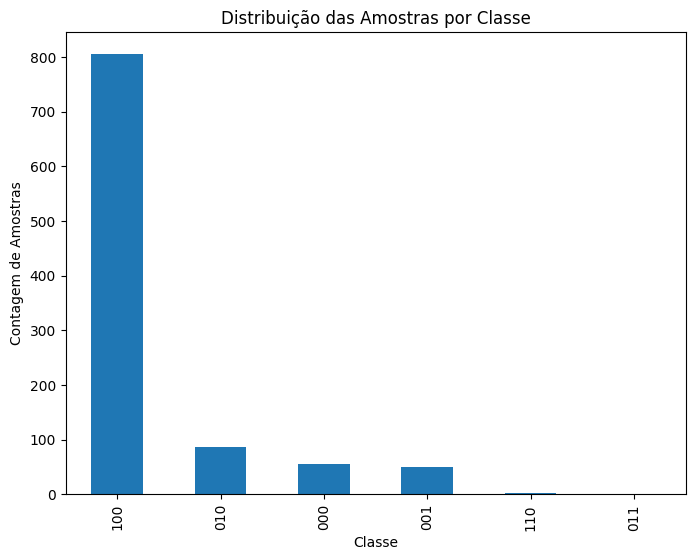

In [55]:
## Distribuicao das amostras
## Histograma da distribuicao das amostras
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 6))
data['rotulo'].value_counts().plot(kind='bar')
plt.title('Distribuição das Amostras por Classe')
plt.xlabel('Classe')
plt.ylabel('Contagem de Amostras')
plt.show()

In [56]:

 
print(f"Configuracao do K-Fold para {folds} folds...")
kf = KFold(n_splits=folds)
kf.get_n_splits(tensor_imagem)
print(kf)
print("K-Fold configurado com sucesso.")

print("Iniciando o treinamento com K-Fold Cross Validation...")

train_loss_total = []
val_loss_total =[]
all_models =[]

 

Configuracao do K-Fold para 2 folds...
KFold(n_splits=2, random_state=None, shuffle=False)
K-Fold configurado com sucesso.
Iniciando o treinamento com K-Fold Cross Validation...


In [57]:
print('''
      ###############################################
      Inicio do treinamento com K-Fold Cross Validation
      ###############################################
      ''')
device = 'cuda:0'


for i, (train_index, test_index) in enumerate(kf.split(patient_id_list)):
    print(f"Fold {i}:")
    #print(f"  Train: index={train_index}")
    #print(f"  Test:  index={test_index}")
    ## init train test for folder
    ## Load images from train test kf


    print(f"\n{'#'*80}")
    print(f"train e val split para fold {len(train_index)}  e {len(test_index)}...")
    print(f'amostras {train_index}')
    ## Obter os patient_id para treino e validação
    train_patient_ids = data.iloc[train_index]
    train_patient_ids = train_patient_ids['patient_id']

    dados_train = data[data['patient_id'].isin(train_patient_ids)]
    print(f"\n{'#'*80}")

    val_patient_ids = data.iloc[test_index]
    val_patient_ids = val_patient_ids['patient_id']

    dados_val = data[data['patient_id'].isin(val_patient_ids)]


    ## 

    train_dataset_part = Subset(data_tensor, dados_train.index)
    val_dataset_part = Subset(data_tensor, dados_val.index)

    train_loader_img = DataLoader(train_dataset_part, batch_size=BATCH_SIZE, shuffle=True)
    val_loader_img = DataLoader(val_dataset_part, batch_size=BATCH_SIZE, shuffle=True)

    model= ECGClassifierResnet()
    if (flg_salvar_modelos):
        salvar_model(model, path='dataset_AFIB_Others/4000-files/output/', name_file=f'model_fold_{i}.pth')
    print(f'Train and valid for Fold {i}')
    # Treina com Early Stopping (patience=5 épocas, delta=0.001)
    t, l,_,outputs,labels = simple_loop(model, train_loader_img, val_loader_img, epochs, batch_size=BATCH_SIZE, fold_index=i, patience=5, delta=0.0001)
    ## Evaluate model.
    train_loss_total.append(t)
    val_loss_total.append(l)

print('''
      ###############################################
      Fim do treinamento com K-Fold Cross Validation
      ###############################################
      ''')
print("Treinamento com K-Fold Cross Validation concluído com sucesso.")


      ###############################################
      Inicio do treinamento com K-Fold Cross Validation
      ###############################################
      
Fold 0:

################################################################################
train e val split para fold 466  e 466...
amostras [466 467 468 469 470 471 472 473 474 475 476 477 478 479 480 481 482 483
 484 485 486 487 488 489 490 491 492 493 494 495 496 497 498 499 500 501
 502 503 504 505 506 507 508 509 510 511 512 513 514 515 516 517 518 519
 520 521 522 523 524 525 526 527 528 529 530 531 532 533 534 535 536 537
 538 539 540 541 542 543 544 545 546 547 548 549 550 551 552 553 554 555
 556 557 558 559 560 561 562 563 564 565 566 567 568 569 570 571 572 573
 574 575 576 577 578 579 580 581 582 583 584 585 586 587 588 589 590 591
 592 593 594 595 596 597 598 599 600 601 602 603 604 605 606 607 608 609
 610 611 612 613 614 615 616 617 618 619 620 621 622 623 624 625 626 627
 628 629 630 631 632 633 634 6

Pasta dataset_AFIB_Others/4000-files/output/ ja existe.
Train and valid for Fold 0
Number of training images per iteration: 64
Device sendo usado: cuda:0
✓ Modelo movido para cuda:0


Training loop:   0%|          | 0/8 [00:22<?, ?it/s]


RuntimeError: Expected floating point type for target with class probabilities, got Long